# Dataset Preparation — Handwritten Digit Classification

Load, preprocess, and merge three handwritten digit datasets into unified PyTorch tensors.
Output (gzip-compressed): `dataset/X_train.pt.gz`, `dataset/y_train.pt.gz`, `dataset/X_val.pt.gz`, `dataset/y_val.pt.gz`

## 1. Setup & Imports

In [1]:
import struct
import gzip
import os
from pathlib import Path
from collections import defaultdict

import numpy as np
from PIL import Image

import torch

from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt

# Config
DATASET_DIR = Path("dataset")
TARGET_SIZE = 28
VAL_SPLIT = 0.10
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Check MPS (Apple Metal) — available for tensor ops, critical for training later
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print(f"MPS device: {DEVICE}")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"CUDA device: {DEVICE}")
else:
    DEVICE = torch.device("cpu")
    print(f"CPU only: {DEVICE}")

# Collectors for merged data
train_X_list = []
train_y_list = []
val_X_list = []
val_y_list = []

MPS device: mps


In [2]:
def show_sample_grid(X, y, title="Samples", n_cols=10, n_rows=3):
    """Display a grid of sample images from each digit class (0-9).
    X: (N, C, H, W) or (N, H, W). y: (N,) integer labels.
    Picks random samples per digit. Shows digit label above each column.
    """
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.4, n_rows * 1.4))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    for col in range(n_cols):
        digit = col  # digit 0–9
        mask = y == digit
        indices = np.where(mask)[0]
        if len(indices) > 0:
            chosen = np.random.choice(indices, min(n_rows, len(indices)), replace=False)
        else:
            chosen = []
        for row in range(n_rows):
            ax = axes[row, col]
            if row < len(chosen):
                idx = chosen[row]
                img = X[idx]
                if img.ndim == 3 and img.shape[0] == 1:
                    img = img[0]  # remove channel dim
                ax.imshow(img, cmap="gray_r")
            ax.axis("off")
            if row == 0:
                ax.set_title(f"'{digit}'", fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 2. EMNIST Digits

**Source**: [NIST EMNIST](https://www.nist.gov/itl/products-and-services/emnist-dataset)  
**Format**: Gzipped IDX binary (MNIST-style)  
**Preprocessing**: Parse binary → float32 [0..1] → invert (white bg, dark digits)  
**Note**: EMNIST images stored transposed; apply `.T` to correct orientation

In [3]:
def parse_idx_images(filepath: Path):
    """Parse IDX image file. Returns (images, num_images, rows, cols)."""
    with gzip.open(filepath, "rb") as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        buf = f.read(num * rows * cols)
        data = np.frombuffer(buf, dtype=np.uint8).reshape(num, rows, cols)
    return data, num, rows, cols


def parse_idx_labels(filepath: Path):
    """Parse IDX label file. Returns (labels, num_labels)."""
    with gzip.open(filepath, "rb") as f:
        magic, num = struct.unpack(">II", f.read(8))
        buf = f.read(num)
        labels = np.frombuffer(buf, dtype=np.uint8)
    return labels, num


emnist_dir = DATASET_DIR / "emnist"

# Load training images & labels
train_imgs, train_n, train_r, train_c = parse_idx_images(
    emnist_dir / "emnist-digits-train-images-idx3-ubyte.gz"
)
train_lbls, train_ln = parse_idx_labels(
    emnist_dir / "emnist-digits-train-labels-idx1-ubyte.gz"
)
print(f"EMNIST train images: {train_imgs.shape}, labels: {train_lbls.shape}")

# Load test images & labels
test_imgs, test_n, test_r, test_c = parse_idx_images(
    emnist_dir / "emnist-digits-test-images-idx3-ubyte.gz"
)
test_lbls, test_ln = parse_idx_labels(
    emnist_dir / "emnist-digits-test-labels-idx1-ubyte.gz"
)
print(f"EMNIST test images: {test_imgs.shape}, labels: {test_lbls.shape}")

EMNIST train images: (240000, 28, 28), labels: (240000,)
EMNIST test images: (40000, 28, 28), labels: (40000,)


In [4]:
def preprocess_emnist(images, labels):
    """Transpose EMNIST images (fix orientation), normalize to [0..1], invert."""
    # EMNIST images stored transposed — rotate/flip to correct view
    processed = np.array([img.reshape(28, 28).T for img in images])
    # Convert uint8 [0..255] → float32 [0.0..1.0]
    processed = processed.astype(np.float32) / 255.0
    # Invert: white background, dark digits
    processed = 1.0 - processed
    # Add channel dimension: (N, 1, 28, 28)
    processed = processed[:, np.newaxis, :, :]
    labels = labels.astype(np.int64)
    return processed, labels


# Preprocess train + test together — all go into our train set (no separate EMNIST val)
emnist_X_all, emnist_y_all = preprocess_emnist(
    np.concatenate([train_imgs, test_imgs]),
    np.concatenate([train_lbls, test_lbls]),
)
print(f"EMNIST combined: X={emnist_X_all.shape}, y={emnist_y_all.shape}")
print(f"  dtype: {emnist_X_all.dtype}, range: [{emnist_X_all.min():.3f}, {emnist_X_all.max():.3f}]")
print(f"  labels: {np.unique(emnist_y_all)}")

train_X_list.append(emnist_X_all)
train_y_list.append(emnist_y_all)

EMNIST combined: X=(280000, 1, 28, 28), y=(280000,)
  dtype: float32, range: [0.000, 1.000]
  labels: [0 1 2 3 4 5 6 7 8 9]


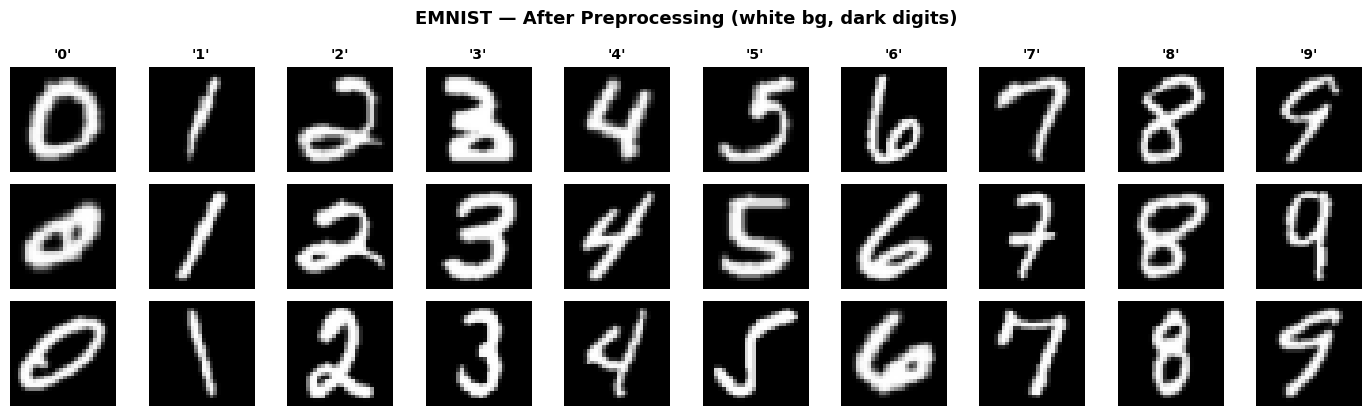

In [5]:
show_sample_grid(emnist_X_all, emnist_y_all, "EMNIST — After Preprocessing (white bg, dark digits)")

## 3. HWD-V1

**Source**: [Kaggle — HWD-V1](https://www.kaggle.com/datasets/metricasecuador/handwritten-digits-version-1-hwd-v1/data)  
**Format**: 52×52 PNG, folders `0/`–`9/` (folder = label)  
**Preprocessing**: Resize 52→28 (LANCZOS), grayscale, float32 [0..1], 10% stratified val split  
**Includes**: Both `HWD-V1-Standard` and `HWD-V1-Edge-Cases`

In [6]:
def load_hwd_v1_images(base_dir: Path):
    """Walk digit folders (0-9), load PNGs, resize, return arrays."""
    images = []
    labels = []
    for digit in range(10):
        digit_dir = base_dir / str(digit)
        if not digit_dir.exists():
            continue
        pngs = sorted(digit_dir.glob("*.png"))
        for png_path in tqdm(pngs, desc=f"  {base_dir.name}/{digit}", leave=False):
            img = Image.open(png_path).convert("L")  # grayscale
            img = img.resize((TARGET_SIZE, TARGET_SIZE), Image.LANCZOS)
            arr = np.array(img, dtype=np.float32) / 255.0
            images.append(arr)
            labels.append(digit)
    return np.array(images), np.array(labels)


hwd_dir = DATASET_DIR / "HWD-V1"

# Load standard
print("Loading HWD-V1 Standard...")
std_X, std_y = load_hwd_v1_images(hwd_dir / "HWD-V1-Standard")
print(f"  Standard: X={std_X.shape}, y={std_y.shape}")

# Load edge cases
print("Loading HWD-V1 Edge Cases...")
edge_X, edge_y = load_hwd_v1_images(hwd_dir / "HWD-V1-Edge-Cases")
print(f"  Edge Cases: X={edge_X.shape}, y={edge_y.shape}")

Loading HWD-V1 Standard...


  Standard: X=(150000, 28, 28), y=(150000,)
Loading HWD-V1 Edge Cases...


  Edge Cases: X=(2138, 28, 28), y=(2138,)


In [7]:
# Merge standard + edge, then stratified 10% val split per digit
hwd_X = np.concatenate([std_X, edge_X])
hwd_y = np.concatenate([std_y, edge_y])
print(f"HWD-V1 merged: X={hwd_X.shape}, y={hwd_y.shape}")

train_idx, val_idx = [], []
for digit in range(10):
    mask = hwd_y == digit
    digit_indices = np.where(mask)[0]
    d_train, d_val = train_test_split(digit_indices, test_size=VAL_SPLIT, random_state=RANDOM_SEED)
    train_idx.extend(d_train)
    val_idx.extend(d_val)

train_idx = np.array(sorted(train_idx))
val_idx = np.array(sorted(val_idx))

hwd_X_train = hwd_X[train_idx]
hwd_y_train = hwd_y[train_idx]
hwd_X_val = hwd_X[val_idx]
hwd_y_val = hwd_y[val_idx]

# Add channel dim: (N, 1, 28, 28)
hwd_X_train = hwd_X_train[:, np.newaxis, :, :]
hwd_X_val = hwd_X_val[:, np.newaxis, :, :]

print(f"  Train: X={hwd_X_train.shape}, y={hwd_y_train.shape}")
print(f"  Val:   X={hwd_X_val.shape}, y={hwd_y_val.shape}")
print(f"  Range: [{hwd_X_train.min():.3f}, {hwd_X_train.max():.3f}], dtype: {hwd_X_train.dtype}")

train_X_list.append(hwd_X_train)
train_y_list.append(hwd_y_train)
val_X_list.append(hwd_X_val)
val_y_list.append(hwd_y_val)

HWD-V1 merged: X=(152138, 28, 28), y=(152138,)
  Train: X=(136920, 1, 28, 28), y=(136920,)
  Val:   X=(15218, 1, 28, 28), y=(15218,)
  Range: [0.000, 1.000], dtype: float32


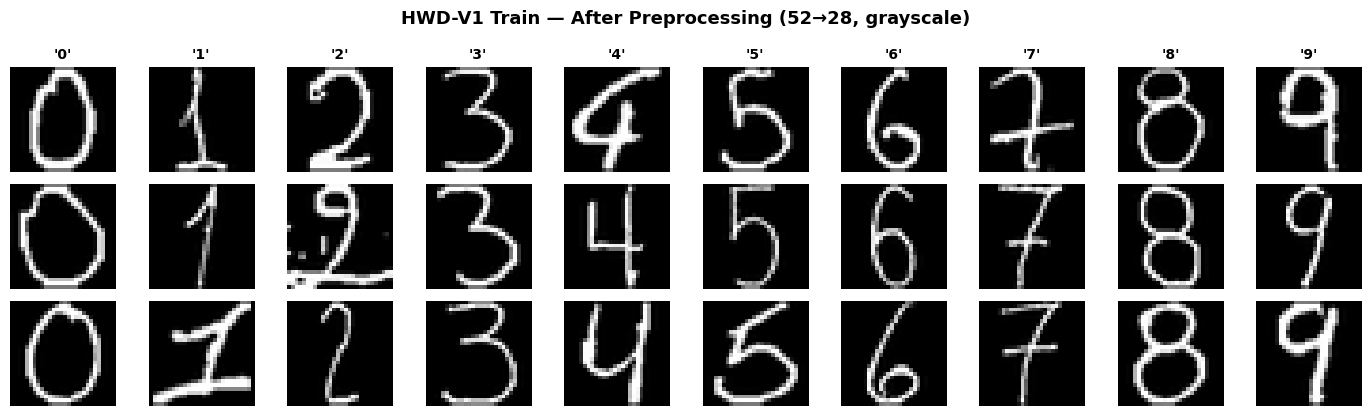

In [8]:
show_sample_grid(hwd_X_train, hwd_y_train, "HWD-V1 Train — After Preprocessing (52→28, grayscale)")

## 4. Handwritten Digits (HuggingFace)

**Source**: [Hugging Face — nguyenminh4099/handwritten-digits](https://huggingface.co/datasets/nguyenminh4099/handwritten-digits)  
**Format**: 28×28 RGBA PNG (transparent bg, dark digits)  
**Preprocessing**: Composite onto white background → grayscale → float32 [0..1]  
**Splits**: Uses built-in train/validation/test — train→our train, validation+test→our val

In [9]:
from datasets import load_dataset

print("Loading nguyenminh4099/handwritten-digits from HuggingFace...")
ds1 = load_dataset("nguyenminh4099/handwritten-digits")
print(f"  Splits: {list(ds1.keys())}")
print(f"  Features: {ds1[list(ds1.keys())[0]].features}")
print(f"  First sample label: {ds1[list(ds1.keys())[0]][0]['label']}")
print(f"  First sample image mode: {ds1[list(ds1.keys())[0]][0]['img'].mode}")
print(f"  First sample image size: {ds1[list(ds1.keys())[0]][0]['img'].size}")

/Users/leocb/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Loading nguyenminh4099/handwritten-digits from HuggingFace...


  Splits: ['train', 'validation', 'test']
  Features: {'img': Image(mode=None, decode=True), 'label': ClassLabel(names=['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine'])}
  First sample label: 9
  First sample image mode: RGBA
  First sample image size: (28, 28)


In [10]:
def image_to_grayscale_arr(img):
    """Convert PIL Image (any mode) to float32 numpy array [0..1], 28x28 grayscale.
    Handles RGBA by compositing onto white background (not black — that loses dark-on-transparent data).
    """
    if img.mode in ("RGBA", "LA"):
        # Composite onto white background so dark-on-transparent digits survive
        bg = Image.new("RGBA", img.size, (255, 255, 255, 255))
        img = Image.alpha_composite(bg, img)
    elif img.mode == "P":
        # Palette images: convert to RGBA first if they have transparency
        img = img.convert("RGBA")
        bg = Image.new("RGBA", img.size, (255, 255, 255, 255))
        img = Image.alpha_composite(bg, img)
    # Now safe to convert to L (all transparent areas replaced with white)
    img = img.convert("L")
    # Resize if needed (this dataset is already 28x28, but be safe)
    if img.size != (TARGET_SIZE, TARGET_SIZE):
        img = img.resize((TARGET_SIZE, TARGET_SIZE), Image.LANCZOS)
    arr = np.array(img, dtype=np.float32) / 255.0
    return arr


def process_hf_dataset_split(split_ds, desc=""):
    """Process one split of an HF dataset. Returns X, y numpy arrays."""
    images = []
    labels = []
    for sample in tqdm(split_ds, desc=desc):
        img = sample["img"]
        lbl = sample["label"]
        arr = image_to_grayscale_arr(img)
        images.append(arr)
        labels.append(int(lbl))
    return np.array(images), np.array(labels)


# Use built-in splits: train → our train, validation + test → our val
print("Processing train split...")
ds1_X_train_raw, ds1_y_train_raw = process_hf_dataset_split(ds1["train"], desc="  train")

print("Processing validation split...")
ds1_X_val_a, ds1_y_val_a = process_hf_dataset_split(ds1["validation"], desc="  val")

print("Processing test split...")
ds1_X_val_b, ds1_y_val_b = process_hf_dataset_split(ds1["test"], desc="  test")

# Merge validation + test into our val set
ds1_X_val = np.concatenate([ds1_X_val_a, ds1_X_val_b])
ds1_y_val = np.concatenate([ds1_y_val_a, ds1_y_val_b])

# Add channel dim: (N, 1, 28, 28)
ds1_X_train = ds1_X_train_raw[:, np.newaxis, :, :]
ds1_X_val = ds1_X_val[:, np.newaxis, :, :]

print(f"\nhandwritten-digits:")
print(f"  Train: X={ds1_X_train.shape}, y={ds1_y_train_raw.shape}, range=[{ds1_X_train.min():.3f}, {ds1_X_train.max():.3f}]")
print(f"  Val:   X={ds1_X_val.shape}, y={ds1_y_val.shape}, range=[{ds1_X_val.min():.3f}, {ds1_X_val.max():.3f}]")
print(f"  Labels: {np.unique(ds1_y_val)}")

train_X_list.append(ds1_X_train)
train_y_list.append(ds1_y_train_raw)
val_X_list.append(ds1_X_val)
val_y_list.append(ds1_y_val)

Processing train split...


  train: 100%|██████████| 86180/86180 [00:05<00:00, 17117.64it/s]


Processing validation split...


  val: 100%|██████████| 10770/10770 [00:00<00:00, 17996.70it/s]


Processing test split...


  test: 100%|██████████| 10770/10770 [00:00<00:00, 17924.33it/s]



handwritten-digits:
  Train: X=(86180, 1, 28, 28), y=(86180,), range=[0.000, 1.000]
  Val:   X=(21540, 1, 28, 28), y=(21540,), range=[0.000, 1.000]
  Labels: [0 1 2 3 4 5 6 7 8 9]


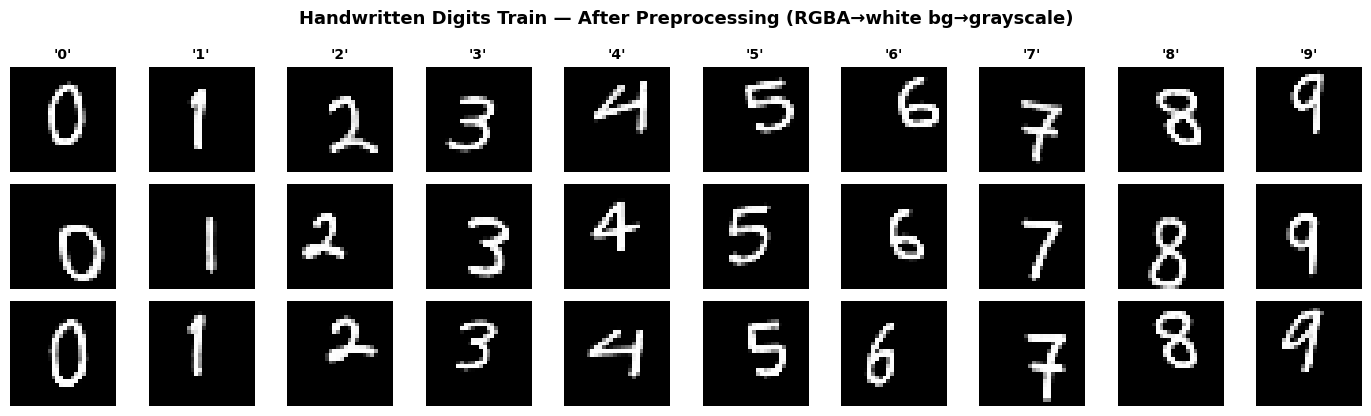

In [11]:
show_sample_grid(ds1_X_train, ds1_y_train_raw, "Handwritten Digits Train — After Preprocessing (RGBA→white bg→grayscale)")

## 5. Merge & Save

Concatenate all datasets into unified tensors and save as gzip-compressed `.pt.gz` files.

To load back: `X_train = torch.load("dataset/X_train.pt.gz", weights_only=True)`

In [12]:
# Merge all collected arrays
X_train = np.concatenate(train_X_list, axis=0)
y_train = np.concatenate(train_y_list, axis=0)
X_val = np.concatenate(val_X_list, axis=0) if val_X_list else np.empty((0, 1, 28, 28), dtype=np.float32)
y_val = np.concatenate(val_y_list, axis=0) if val_y_list else np.empty((0,), dtype=np.int64)

# Shuffle training set
train_perm = np.random.permutation(len(y_train))
X_train = X_train[train_perm]
y_train = y_train[train_perm]

print(f"Final Train: X={X_train.shape}, y={y_train.shape}")
print(f"Final Val:   X={X_val.shape}, y={y_val.shape}")
print(f"  dtype: {X_train.dtype}, range: [{X_train.min():.3f}, {X_train.max():.3f}]")

# Label distribution
for lbl in range(10):
    train_count = (y_train == lbl).sum()
    val_count = (y_val == lbl).sum()
    print(f"  Digit {lbl}: train={train_count}, val={val_count}")

Final Train: X=(503100, 1, 28, 28), y=(503100,)
Final Val:   X=(36758, 1, 28, 28), y=(36758,)
  dtype: float32, range: [0.000, 1.000]
  Digit 0: train=50423, val=3688
  Digit 1: train=50368, val=3682
  Digit 2: train=50373, val=3683
  Digit 3: train=50315, val=3676
  Digit 4: train=50262, val=3671
  Digit 5: train=50274, val=3672
  Digit 6: train=50259, val=3670
  Digit 7: train=50275, val=3672
  Digit 8: train=50273, val=3672
  Digit 9: train=50278, val=3672


In [18]:
# Convert to torch tensors and save with gzip compression
X_train_pt = torch.from_numpy(X_train)
y_train_pt = torch.from_numpy(y_train)
X_val_pt = torch.from_numpy(X_val)
y_val_pt = torch.from_numpy(y_val)

save_dir = DATASET_DIR
for name, tensor in [("X_train", X_train_pt), ("y_train", y_train_pt),
                      ("X_val",   X_val_pt),   ("y_val",   y_val_pt)]:
    path = save_dir / f"{name}.pt.gz"
    with gzip.open(path, "wb") as f:
        torch.save(tensor, f)

print(f"Saved to {save_dir}/:")
for f in ["X_train.pt.gz", "y_train.pt.gz", "X_val.pt.gz", "y_val.pt.gz"]:
    path = save_dir / f
    size_mb = path.stat().st_size / (1024 * 1024)
    print(f"  {f}: {size_mb:.1f} MB")

Saved to dataset/:
  X_train.pt.gz: 198.1 MB
  y_train.pt.gz: 0.3 MB
  X_val.pt.gz: 10.5 MB
  y_val.pt.gz: 0.0 MB


## 6. Summary & Visualization

DATASET SUMMARY
Training samples:   503,100
Validation samples: 36,758
Total:              539,858
Image shape:        (1, 28, 28) (C×H×W)
Value range:        [0.0000, 1.0000]
Device available:   mps


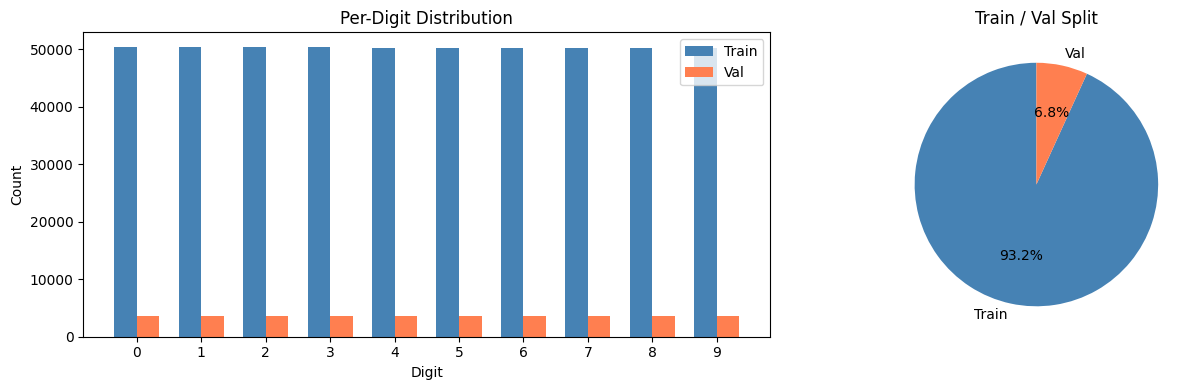

In [14]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Training samples:   {len(y_train):,}")
print(f"Validation samples: {len(y_val):,}")
print(f"Total:              {len(y_train) + len(y_val):,}")
print(f"Image shape:        {X_train.shape[1:]} (C×H×W)")
print(f"Value range:        [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"Device available:   {DEVICE}")

# Per-digit distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
digits = list(range(10))
train_counts = [(y_train == d).sum() for d in digits]
val_counts = [(y_val == d).sum() for d in digits]

x = np.arange(len(digits))
w = 0.35
ax[0].bar(x - w/2, train_counts, w, label="Train", color="steelblue")
ax[0].bar(x + w/2, val_counts, w, label="Val", color="coral")
ax[0].set_xlabel("Digit")
ax[0].set_ylabel("Count")
ax[0].set_title("Per-Digit Distribution")
ax[0].set_xticks(x)
ax[0].legend()

# Pie chart: train vs val split
ax[1].pie([len(y_train), len(y_val)], labels=["Train", "Val"], autopct="%1.1f%%",
          colors=["steelblue", "coral"], startangle=90)
ax[1].set_title("Train / Val Split")

plt.tight_layout()
plt.show()

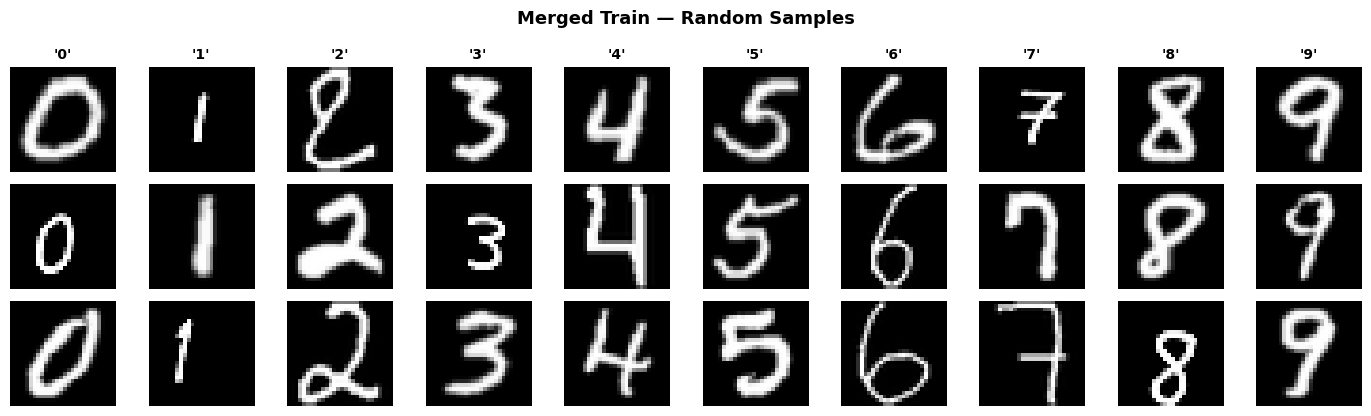

In [15]:
show_sample_grid(X_train, y_train, "Merged Train — Random Samples")

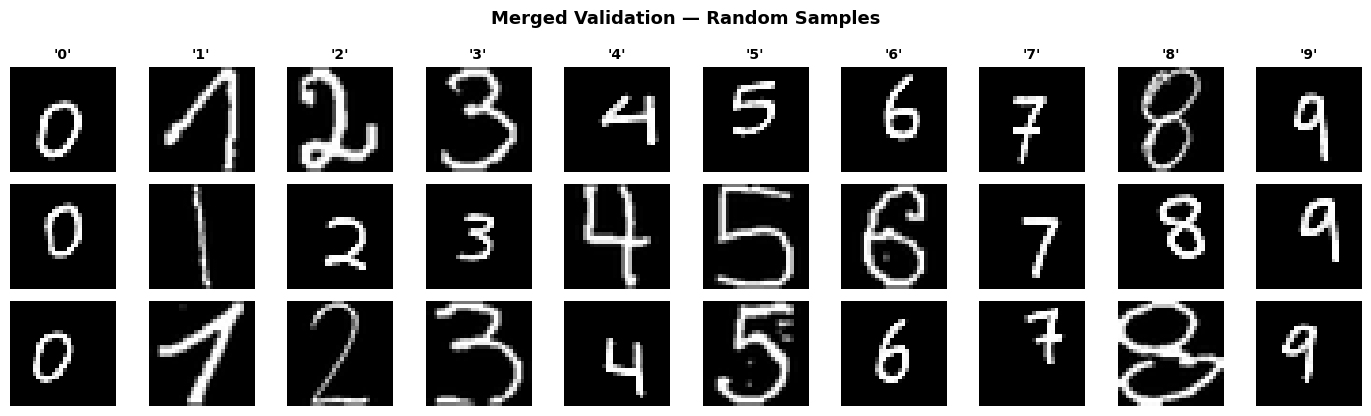

In [16]:
show_sample_grid(X_val, y_val, "Merged Validation — Random Samples")

In [17]:
print("Done. Ready for training.")

Done. Ready for training.
